In [2]:
!pip install pandas numpy matplotlib seaborn scikit-learn joblib

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

In [4]:
from google.colab import files

uploaded = files.upload()

Saving House Prediction data set.csv to House Prediction data set (1).csv


In [5]:
df = pd.read_csv("/content/House Prediction data set.csv")

df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [6]:
print(df.info())
print(df.isnull().sum())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

In [7]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_490/3551297251.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [8]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_490/2422164989.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [4]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("/content/House Prediction data set.csv")
cat_cols = df.select_dtypes(include='object').columns

le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

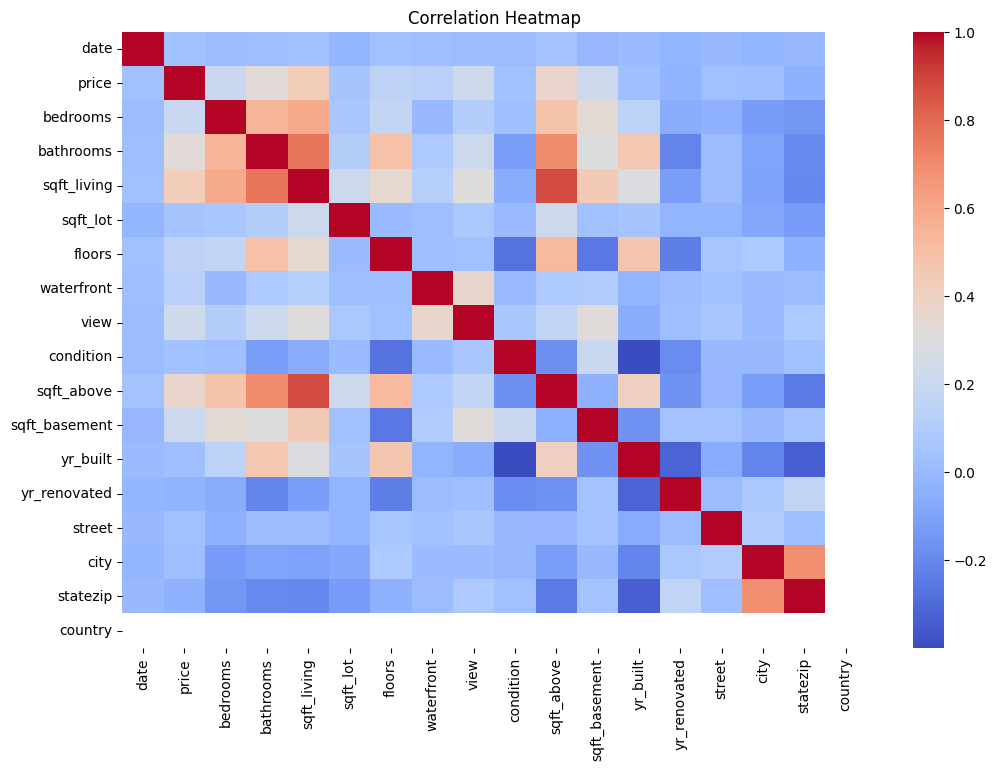

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

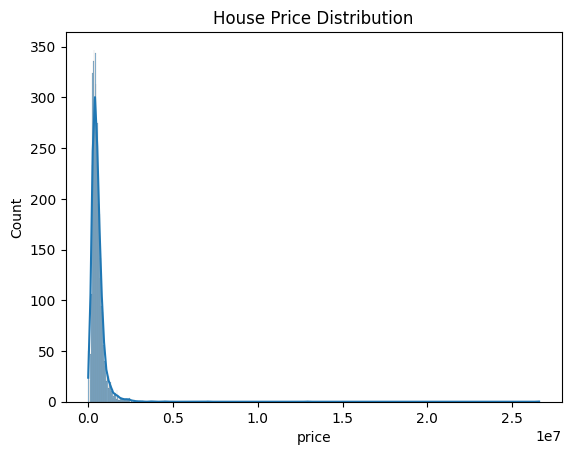

In [8]:
sns.histplot(df['price'], kde=True)

plt.title("House Price Distribution")

plt.show()

In [10]:
import numpy as np
df['price'] = np.log1p(df['price'])

In [12]:
X = df.drop('price', axis=1)

y = df['price']

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

LinearRegression()

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [19]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [22]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [24]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor()

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(name, y_test, pred):

    mae = mean_absolute_error(y_test, pred)

    rmse = np.sqrt(mean_squared_error(y_test, pred))

    r2 = r2_score(y_test, pred)

    print(f"{name} Results")
    print("-"*30)
    print("MAE :", mae)
    print("RMSE:", rmse)
    print("R2 Score:", r2)
    print()

In [28]:
evaluate_model("Linear Regression", y_test, lr_pred)

evaluate_model("Random Forest", y_test, rf_pred)

evaluate_model("Gradient Boosting", y_test, gb_pred)

Linear Regression Results
------------------------------
MAE : 0.46827769982991607
RMSE: 1.385223567226349
R2 Score: 0.02107173462843115

Random Forest Results
------------------------------
MAE : 0.46221817285483335
RMSE: 1.4457253342846013
R2 Score: -0.06630809921976155

Gradient Boosting Results
------------------------------
MAE : 0.4767564624765364
RMSE: 1.4711170562842741
R2 Score: -0.10409282220003457



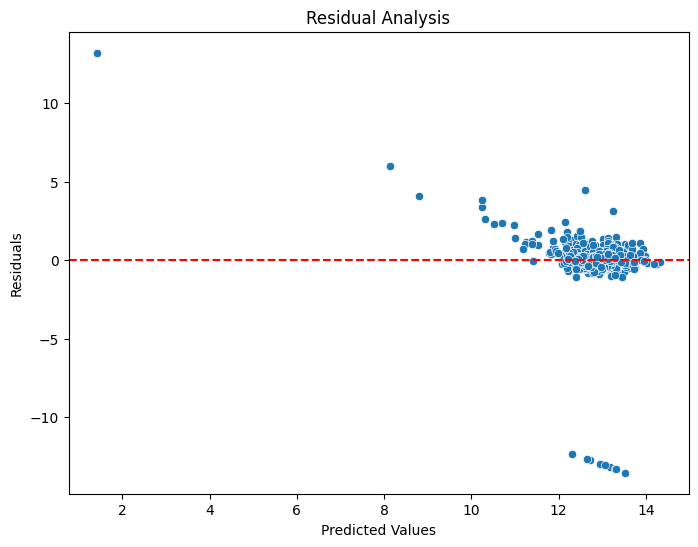

In [29]:
residuals = y_test - gb_pred

plt.figure(figsize=(8,6))

sns.scatterplot(x=gb_pred, y=residuals)

plt.axhline(y=0, color='r', linestyle='--')

plt.xlabel("Predicted Values")

plt.ylabel("Residuals")

plt.title("Residual Analysis")

plt.show()

In [31]:
import joblib
joblib.dump(gb, 'house_price_model.pkl')

['house_price_model.pkl']

In [33]:
sample = X.iloc[0:1]

prediction = gb.predict(sample)

prediction = np.expm1(prediction)

print("Predicted House Price:", prediction[0])

Predicted House Price: 4.895018779574505


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but GradientBoostingRegressor was fitted without feature names
  warnings.warn(


In [34]:

from google.colab import files

files.download('house_price_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>